# Spread Mean-Reversion Backtester — HyperLiquid vs MT5 (JPY)

Runs the strategy from `spread_backtester.py`, with three additions on top of a
single backtest run: Sharpe/Sortino, a frozen train/test split, and a walk-forward
test across sequential windows.

**Data window limitation, read this first:** HyperLiquid's public `candleSnapshot`
endpoint only exposes the **most recent 5000 candles** — at 1-minute resolution
that's ~3.5 days, regardless of your MT5 file's longer history. Your real MT5 CSV
has ~3 months of data, but the HL/MT5 join will only cover whatever recent window
HL's API currently has for 1m bars. If you want a longer real backtest window,
switch `hl_interval` below to `"5m"` or `"15m"` (same 5000-candle cap, but each
candle covers more calendar time — 5m → ~17 days, 15m → ~52 days) at the cost of
trading less frequently.

**On small samples:** with only a few days of real data, don't over-read any single
run's Sharpe, win rate, or "the strategy is/isn't viable" — 3-4 daily observations
isn't enough to distinguish real edge from noise. Treat early real-data runs as
diagnostic (is this cost-driven or signal-driven?), not conclusive.

In [30]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from spread_backtester import (
    StrategyConfig, SpreadBacktester, load_price_data,
    train_test_split_test, walk_forward_test,
)

pd.set_option("display.width", 120)
plt.rcParams["figure.figsize"] = (12, 5)

## 1. Load data

Loads your real MT5 CSV export and pulls the matching HyperLiquid historical
window over REST, joined on timestamp. Switch `hl_interval` to `"5m"` or `"15m"`
for a longer real window (see note above).

In [31]:
data = load_price_data(
    mt5_csv_path="USDJPYM5.csv",
    hl_coin="xyz:JPY",
    hl_interval="5m",   # try "5m" or "15m" for a longer real backtest window
    mt5_tz=None,
)

print(f"{len(data):,} aligned bars")
print(f"{data.index.min()}  ->  {data.index.max()}")
data.tail()

3,851 aligned bars
2026-07-28 06:55:00+00:00  ->  2026-08-14 15:40:00+00:00


,hl_close,mt5_close
datetime,,
2026-08-14 15:25:00+00:00,159.12,158.803
2026-08-14 15:30:00+00:00,159.12,158.702
2026-08-14 15:35:00+00:00,159.10,158.831
2026-08-14 15:40:00+00:00,159.14,158.905
2026-08-14 15:40:00+00:00,159.14,158.905


## 2. Strategy configuration — frozen for the rest of this notebook

Pick this once. Every section below reuses `cfg` unchanged.

In [63]:
cfg = StrategyConfig(
    entry_sigma=2.0,
    exit_sigma=0.0,
    stop_sigma_extra=1.0,
    risk_pct_per_trade=0.01,
    max_drawdown_pct=0.10,
    order_type="market",
    rolling=True,
    lookback_bars=500,     # ~1 day of 1-min bars -- shrink this if using a short real data window
    starting_equity=10_000.0,
)
cfg

StrategyConfig(lookback_bars=500, rolling=True, entry_sigma=2.0, exit_sigma=0.0, stop_sigma_extra=1.0, order_type='market', hl_taker_fee_pct=0.009, hl_maker_fee_pct=0.003, market_order_slippage_pct=0.01, slippage_curve={}, mt5_spread=0.001, mt5_fee=0.0, reference_price=159.308, risk_pct_per_trade=0.01, point_value=0.006277148667989053, max_drawdown_pct=0.1, starting_equity=10000.0)

## 3. Full-period backtest — now with gross vs. net P&L

`total_gross_pnl` is the raw spread capture before costs. `total_commission` is
fees + slippage. If gross is positive but net is negative, that's a **cost
problem** (parameters, fee tier, order type). If gross is also negative, that's
a **signal problem** (the mean-reversion premise itself isn't holding up on this
window) — a meaningfully different diagnosis, worth telling apart before
concluding anything about viability.

In [64]:
bt_full = SpreadBacktester(data, cfg)
summary_full = bt_full.run()

for k, v in summary_full.items():
    print(f"{k:>22}: {v}")

                trades: 34
          win_rate_pct: 29.41176470588235
       total_gross_pnl: 316.02394944499576
         total_net_pnl: -903.1448906425684
      total_commission: 1219.1688400875641
             avg_trade: -26.56308501889907
      max_drawdown_pct: 10.356739026402195
         ending_equity: 9096.855109357432
 halted_by_kill_switch: True
             halted_at: 2026-07-30 13:55:00+00:00
                sharpe: -4.81935357947002
               sortino: -2.0719951597588766
           n_daily_obs: 13


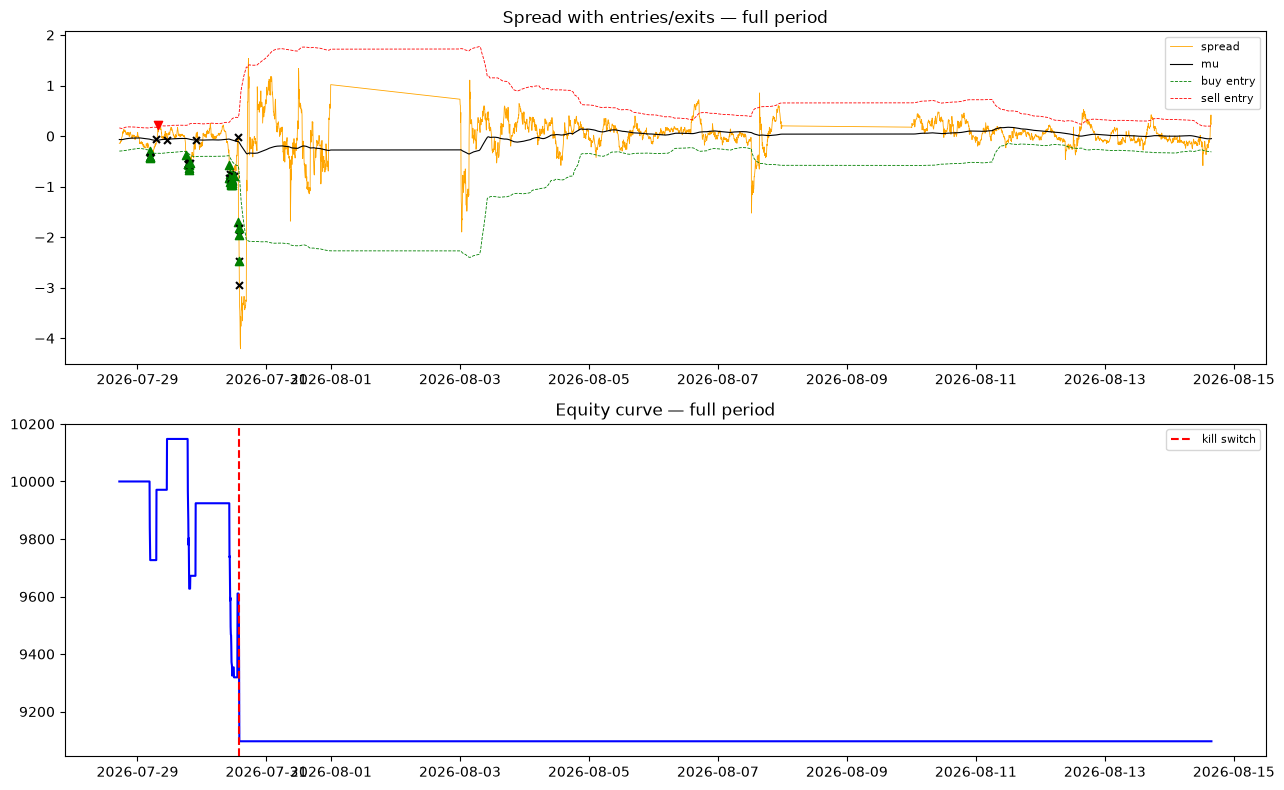

In [65]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=False)

d = bt_full.bands_df
axes[0].plot(d.index, d["spread"], color="orange", linewidth=0.6, label="spread")
axes[0].plot(d.index, d["mu"], color="black", linewidth=0.8, label="mu")
axes[0].plot(d.index, d["buy_entry"], "--", color="green", linewidth=0.6, label="buy entry")
axes[0].plot(d.index, d["sell_entry"], "--", color="red", linewidth=0.6, label="sell entry")
for t in bt_full.trades:
    marker = "^" if t.side == "long" else "v"
    color = "green" if t.side == "long" else "red"
    axes[0].scatter(t.entry_time, t.entry_price, marker=marker, color=color, s=35, zorder=5)
    if t.exit_time:
        axes[0].scatter(t.exit_time, t.exit_price, marker="x", color="black", s=25, zorder=5)
axes[0].set_title("Spread with entries/exits — full period")
axes[0].legend(fontsize=8, loc="upper right")

axes[1].plot(bt_full.equity_df.index, bt_full.equity_df["equity"], color="blue")
axes[1].set_title("Equity curve — full period")
if bt_full.halted_at:
    axes[1].axvline(bt_full.halted_at, color="red", linestyle="--", label="kill switch")
    axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 4. Train / test split (out-of-sample check)

First half of the data = train, second half = test. `cfg` is not re-tuned
between the two.

In [66]:
oos = train_test_split_test(data, cfg, train_frac=0.5)
bt_train, stats_train = oos["train"]
bt_test, stats_test = oos["test"]

comparison = pd.DataFrame([stats_train, stats_test], index=["train (in-sample)", "test (out-of-sample)"])
comparison[["trades", "win_rate_pct", "total_gross_pnl", "total_commission",
            "total_net_pnl", "max_drawdown_pct", "sharpe", "sortino", "halted_by_kill_switch"]]

,trades,win_rate_pct,total_gross_pnl,total_commission,total_net_pnl,max_drawdown_pct,sharpe,sortino,halted_by_kill_switch
train (in-sample),34,29.411765,316.023949,1219.168840,-903.144891,10.356739,-7.170829,-4.489323,True
test (out-of-sample),10,0.000000,-319.612242,707.601413,-1027.213655,10.272137,NaN,NaN,True


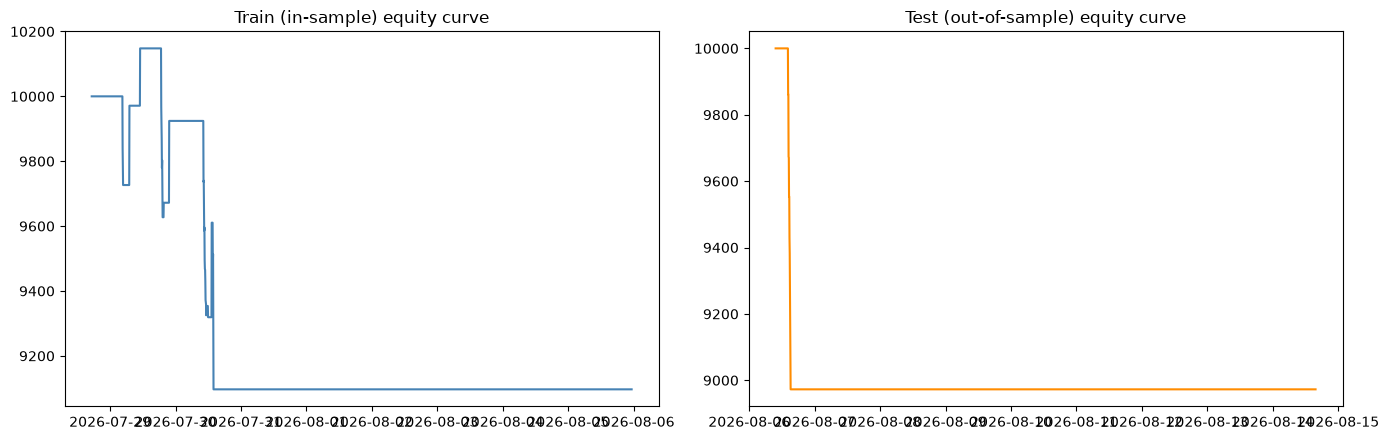

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=False)
axes[0].plot(bt_train.equity_df.index, bt_train.equity_df["equity"], color="steelblue")
axes[0].set_title("Train (in-sample) equity curve")
axes[1].plot(bt_test.equity_df.index, bt_test.equity_df["equity"], color="darkorange")
axes[1].set_title("Test (out-of-sample) equity curve")
plt.tight_layout()
plt.show()

## 5. Walk-forward test

Splits the full period into sequential folds and runs the same frozen `cfg` on
each in order (equity compounds fold-to-fold). Zero-trade folds are now handled
correctly (previously crashed).

In [68]:
wf = walk_forward_test(data, cfg, n_folds=6, compound=True)
fold_stats = wf["fold_stats"]

cols = ["fold", "fold_start", "fold_end", "trades", "win_rate_pct",
        "total_gross_pnl", "total_commission", "total_net_pnl",
        "max_drawdown_pct", "sharpe", "sortino", "ending_equity"]
fold_stats[cols]

,fold,fold_start,fold_end,trades,win_rate_pct,total_gross_pnl,total_commission,total_net_pnl,max_drawdown_pct,sharpe,sortino,ending_equity
0,1,2026-07-28 06:55:00+00:00,2026-07-30 12:15:00+00:00,29,27.586207,425.715808,1106.570789,-680.854980,8.166225,-14.408778,-14.408778,9319.145020
1,2,2026-07-30 12:20:00+00:00,2026-08-03 17:40:00+00:00,0,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,9319.145020
2,3,2026-08-03 17:45:00+00:00,2026-08-05 23:05:00+00:00,9,33.333333,536.294709,275.820885,260.473824,4.436514,NaN,NaN,9579.618844
3,4,2026-08-05 23:10:00+00:00,2026-08-10 04:30:00+00:00,10,0.000000,-353.068319,640.781688,-993.850007,10.374630,NaN,NaN,8585.768836
4,5,2026-08-10 04:35:00+00:00,2026-08-12 09:55:00+00:00,4,100.000000,714.743848,176.716034,538.027815,0.000000,13.578854,NaN,9123.796651
5,6,2026-08-12 10:00:00+00:00,2026-08-14 15:40:00+00:00,5,40.000000,349.344446,219.490984,129.853461,3.074059,6.222448,NaN,9253.650113


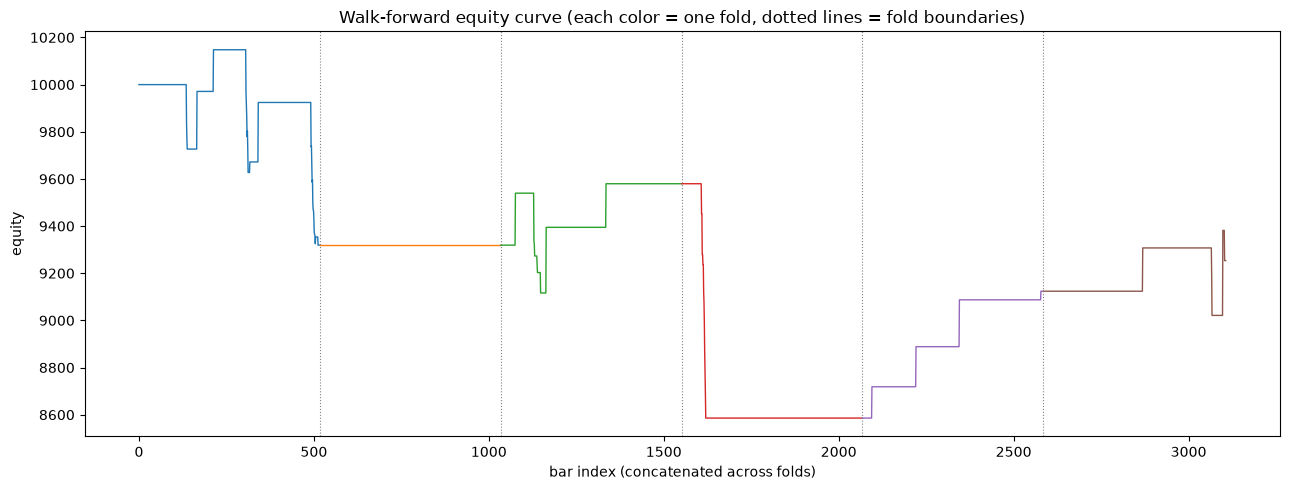

Win rate across folds: mean 33.5%, std 36.7pp
Gross PnL across folds: mean 278.84, std 389.85
Net PnL across folds:   mean -124.39, std 588.67

Compare gross vs net mean here: if gross is consistently positive across folds
but net is not, costs are the dominant problem, not the signal. If gross is
also inconsistent/negative across folds, that's evidence against a stable edge.


In [69]:
fig, ax = plt.subplots(figsize=(13, 5))

offset = 0
boundaries = []
for bt in wf["backtesters"]:
    eq = bt.equity_df["equity"]
    x = range(offset, offset + len(eq))
    ax.plot(x, eq.values, linewidth=1)
    offset += len(eq)
    boundaries.append(offset)

for b in boundaries[:-1]:
    ax.axvline(b, color="gray", linestyle=":", linewidth=0.8)

ax.set_title("Walk-forward equity curve (each color = one fold, dotted lines = fold boundaries)")
ax.set_xlabel("bar index (concatenated across folds)")
ax.set_ylabel("equity")
plt.tight_layout()
plt.show()

print(f"Win rate across folds: mean {fold_stats['win_rate_pct'].mean():.1f}%, std {fold_stats['win_rate_pct'].std():.1f}pp")
print(f"Gross PnL across folds: mean {fold_stats['total_gross_pnl'].mean():.2f}, std {fold_stats['total_gross_pnl'].std():.2f}")
print(f"Net PnL across folds:   mean {fold_stats['total_net_pnl'].mean():.2f}, std {fold_stats['total_net_pnl'].std():.2f}")
print()
print("Compare gross vs net mean here: if gross is consistently positive across folds")
print("but net is not, costs are the dominant problem, not the signal. If gross is")
print("also inconsistent/negative across folds, that's evidence against a stable edge.")

## Reading these results

- **Gross vs. net**: the single most useful diagnostic added this round. Positive
  gross + negative net = fix costs/parameters. Negative gross = the mean-reversion
  premise itself isn't holding on this window/asset pair.
- **Data window**: real conclusions need more than ~3.5 days. Re-run with `hl_interval`
  set to `"5m"` or `"15m"` for a longer real history before drawing firm conclusions.
- **Sharpe/Sortino** with `n_daily_obs` under ~10-15 should be treated as
  illustrative, not decisive.
- **Walk-forward variance**: low variance across folds is stronger evidence of a
  repeatable edge than any single good full-period number.
- None of this is investment advice, and a clean walk-forward result on historical
  data still doesn't guarantee future live performance.